In [4]:
# ==============================================================================
# PHẦN 1: EDA & KỸ NGHỆ ĐẶC TRƯNG HÀNH VI KHÁCH HÀNG (DỮ LIỆU THỰC TẾ)
# Thực hiện: Thành viên B (Data Analyst)
# ==============================================================================

# Cell 1: Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cấu hình hiển thị
%matplotlib inline
sns.set_theme(style="whitegrid")

In [5]:
# Cell 2: Đọc tập dữ liệu đã được tổng hợp (từ file 00_generate)
current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir) if 'notebooks' in current_dir else current_dir
file_path = os.path.join(base_dir, 'data', 'processed', 'real_world_mobile_data.csv')

print(f"Đang đọc dữ liệu từ: {file_path}")
df = pd.read_csv(file_path)

print(f"Kích thước tập dữ liệu: {df.shape}")
display(df.head())

Đang đọc dữ liệu từ: d:\CDIO\mobile-clv-prediction\data\processed\real_world_mobile_data.csv
Kích thước tập dữ liệu: (5000, 15)


,Customer_ID,Customer_Age,Location_Type,Membership_Months,Frequency,Recency,Favorite_Brand,Monetary,Installment_Rate,Flagship_Ratio,Accessories_Ratio,Credit_Card_Usage,Warranty_Claims,App_Logins_L30D,Is_VIP
0,CUST_00001,31,Tier 1,8,4,177,Apple,53740000,0.177151,0.921343,0.959813,0.333280,1,34,1
1,CUST_00002,26,Tier 1,34,5,76,Samsung,55230000,0.149226,0.607037,0.670104,0.219574,1,16,1
2,CUST_00003,33,Tier 2,59,1,181,Samsung,7940000,0.939033,0.535265,0.432770,0.748441,0,38,0
3,CUST_00004,40,Tier 1,18,1,150,Xiaomi,7830000,0.698156,0.993991,0.112255,0.090838,1,42,0
4,CUST_00005,26,Tier 1,31,3,82,Apple,62760000,0.411286,0.579426,0.385186,0.940858,0,3,1


In [6]:
# Cell 3: Kiểm tra cấu trúc dữ liệu và giá trị khuyết thiếu
print("--- Thông tin dữ liệu ---")
df.info()
print("\n--- Kiểm tra Missing Values ---")
print(df.isnull().sum())

--- Thông tin dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        5000 non-null   object 
 1   Customer_Age       5000 non-null   int64  
 2   Location_Type      5000 non-null   object 
 3   Membership_Months  5000 non-null   int64  
 4   Frequency          5000 non-null   int64  
 5   Recency            5000 non-null   int64  
 6   Favorite_Brand     5000 non-null   object 
 7   Monetary           5000 non-null   int64  
 8   Installment_Rate   5000 non-null   float64
 9   Flagship_Ratio     5000 non-null   float64
 10  Accessories_Ratio  5000 non-null   float64
 11  Credit_Card_Usage  5000 non-null   float64
 12  Warranty_Claims    5000 non-null   int64  
 13  App_Logins_L30D    5000 non-null   int64  
 14  Is_VIP             5000 non-null   int64  
dtypes: float64(4), int64(8), object(3)
memory usag

d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


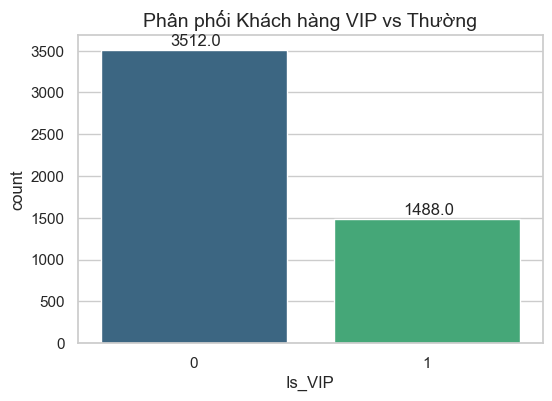

In [7]:
# Cell 4: Phân tích Khám phá Dữ liệu (EDA) - Cốt lõi
# 4.1. Phân phối của Nhãn VIP (Target Variable)
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Is_VIP', data=df, palette='viridis')
plt.title("Phân phối Khách hàng VIP vs Thường", fontsize=14)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 50))
plt.show()

d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.v

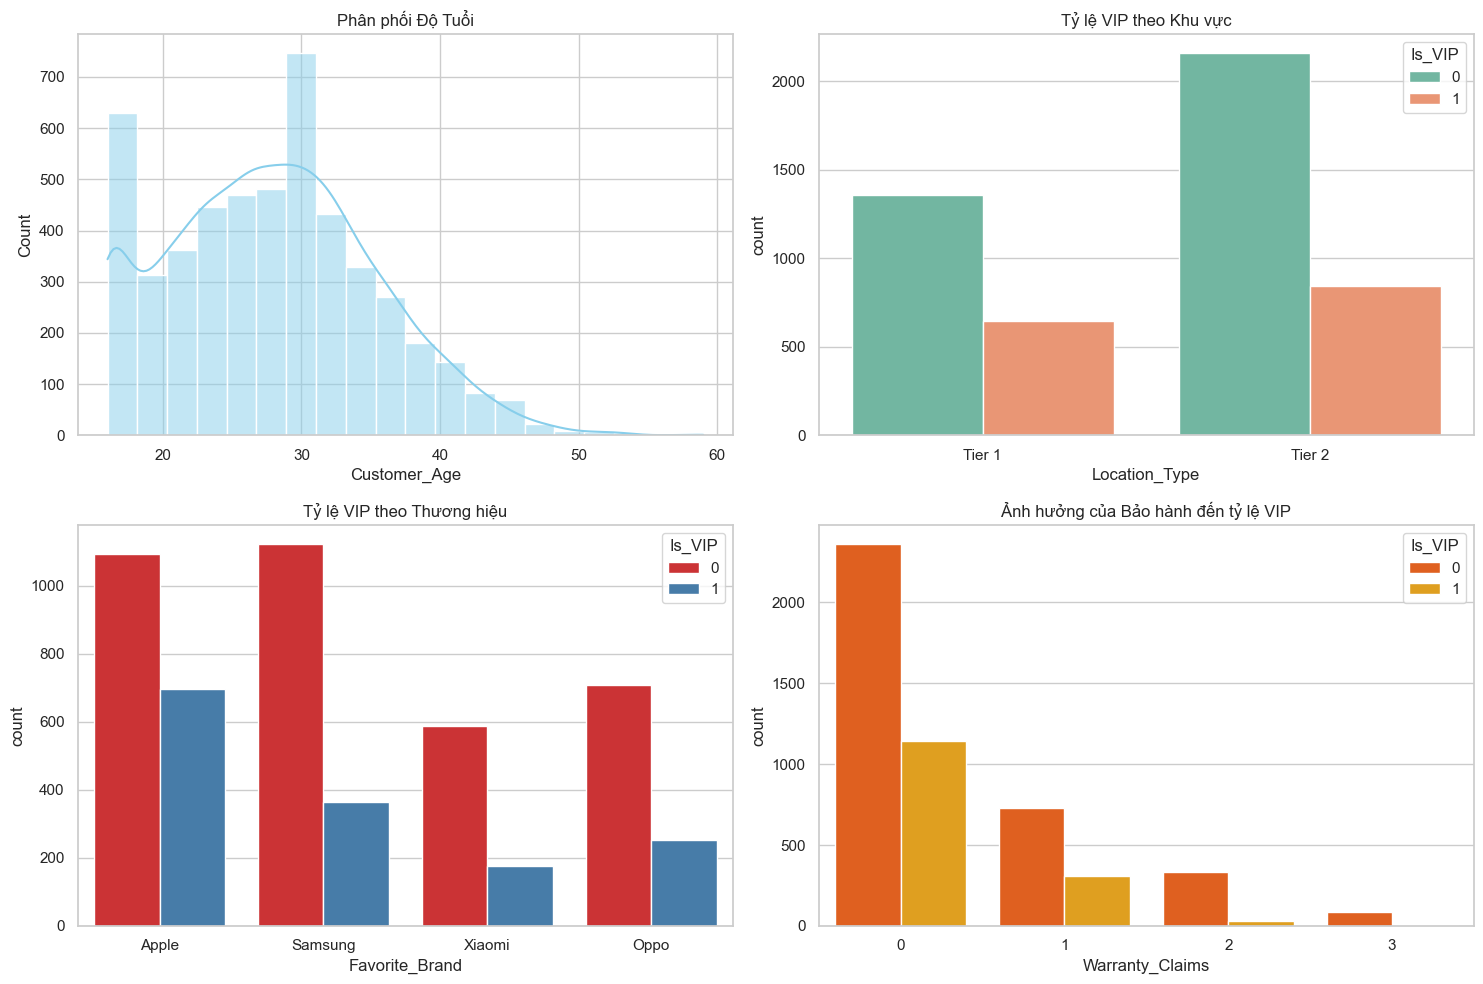

In [8]:
# Cell 5: Phân tích Nhân khẩu học & Hành vi
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Tuổi
sns.histplot(df['Customer_Age'], bins=20, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Phân phối Độ Tuổi')

# Khu vực sống
sns.countplot(x='Location_Type', hue='Is_VIP', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Tỷ lệ VIP theo Khu vực')

# Thương hiệu yêu thích
sns.countplot(x='Favorite_Brand', hue='Is_VIP', data=df, ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Tỷ lệ VIP theo Thương hiệu')

# Số lần đi bảo hành (Nỗi đau doanh nghiệp)
sns.countplot(x='Warranty_Claims', hue='Is_VIP', data=df, ax=axes[1, 1], palette='autumn')
axes[1, 1].set_title('Ảnh hưởng của Bảo hành đến tỷ lệ VIP')

plt.tight_layout()
plt.show()

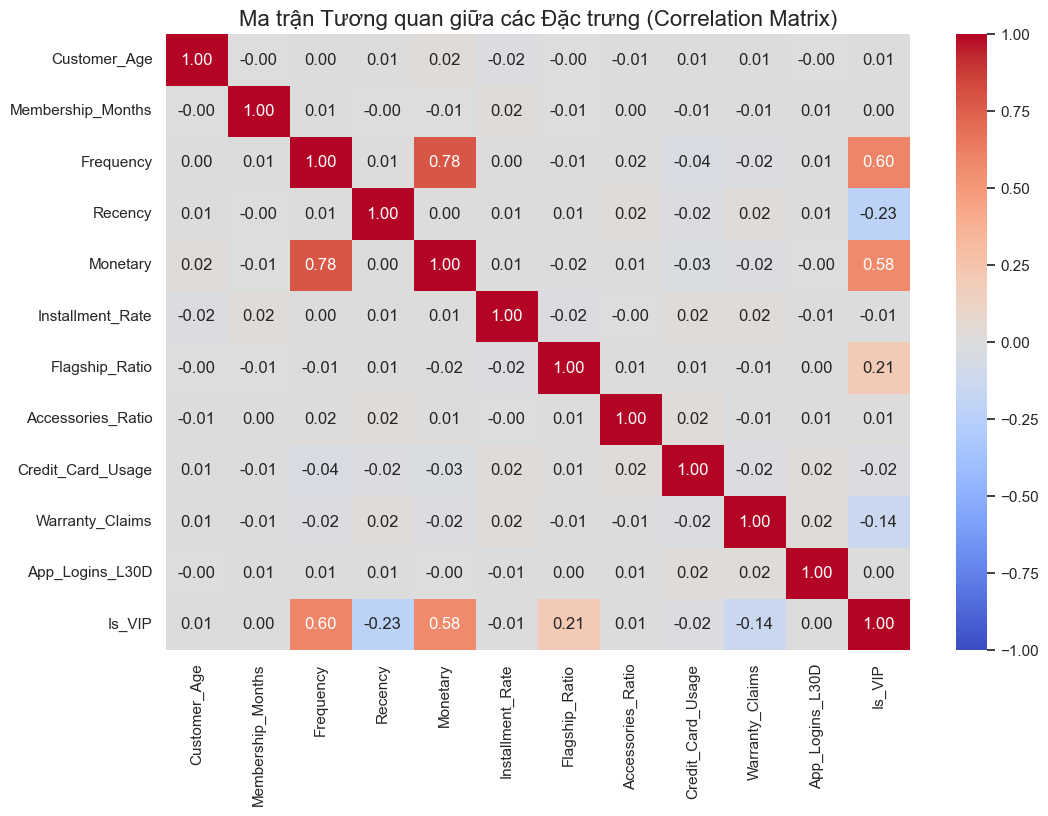

In [9]:
# Cell 6: Phân tích tương quan (Correlation Matrix)
# Loại bỏ các cột không phải số để tính tương quan
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Ma trận Tương quan giữa các Đặc trưng (Correlation Matrix)", fontsize=16)
plt.show()

In [10]:
# Cell 7: Lưu lại thành file customer_features chuẩn bị cho Training
output_dir = os.path.join(base_dir, 'data', 'processed')
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'customer_features.csv')
df.to_csv(output_path, index=False)

print(f"✅ Đã phân tích xong và lưu tập đặc trưng tại: {output_path}")

✅ Đã phân tích xong và lưu tập đặc trưng tại: d:\CDIO\mobile-clv-prediction\data\processed\customer_features.csv
